In [1]:
# ── 4.0  IMPORTS ─────────────────────────────────────────────
import os, json, time, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
import torch.nn.utils.rnn as rnn_utils
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report, f1_score, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from collections import Counter

In [2]:
# ── 4.1  REPRODUCIBILITY ──────────────────────────────────────
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
os.makedirs('../results', exist_ok=True)
os.makedirs('../models', exist_ok=True)


Device: cuda


In [3]:
# ── 4.3  HYPERPARAMETERS ──────────────────────────────────────
VOCAB_SIZE    = 15_000
MAX_LEN       = 80
EMBED_DIM     = 100
HIDDEN_DIM    = 64
ATTN_HEADS    = 4
EMBED_DROP    = 0.2
CLF_DROP      = 0.3
FOCAL_GAMMA   = 2.0
BATCH_SIZE    = 64
PEAK_LR       = 1.5e-3
WEIGHT_DECAY  = 1e-4
EPOCHS        = 10
PATIENCE      = 5
NUM_CLASSES   = 3
NUM_WORKERS   = 0  

In [4]:
# ── 4.4  LOAD DATA ────────────────────────────────────────────
df_train = pd.read_csv('../data/train.csv')
df_val   = pd.read_csv('../data/val.csv')
df_test  = pd.read_csv('../data/test.csv')

with open('../data/class_weights.json') as f:
    cw_dict = {int(k): v for k, v in json.load(f).items()}

cw_list   = [cw_dict[i] for i in range(3)]
cw_tensor = torch.tensor(cw_list, dtype=torch.float).to(DEVICE)

CLASS_NAMES = ['Negative', 'Neutral', 'Positive']


In [ ]:
pip install torchtext

In [10]:
# ── 4.2  BUILD VOCABULARY & DATASET ───────────────────────────
from collections import Counter
import os
import urllib.request
import zipfile

# 1. Build the vocabulary
counter = Counter()
for text in df_train['combined_text'].fillna('').astype(str):
    counter.update(str(text).lower().split())

vocab = ['<PAD>', '<UNK>'] + [tok for tok, cnt in counter.most_common(VOCAB_SIZE - 2) if cnt >= 2]
word2idx = {w: i for i, w in enumerate(vocab)}

def encode(text, max_len=MAX_LEN):
    tokens = str(text).lower().split()[:max_len]
    ids = [word2idx.get(t, 1) for t in tokens]
    length = len(ids)
    ids += [0] * (max_len - length)
    return ids, length

class TextDataset(Dataset):
    def __init__(self, df):
        self.texts  = df['combined_text'].fillna('').astype(str).values
        self.labels = df['label'].values
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        ids, length = encode(self.texts[idx])
        return torch.tensor(ids, dtype=torch.long), torch.tensor(length, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)

train_loader = DataLoader(TextDataset(df_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TextDataset(df_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TextDataset(df_test), batch_size=BATCH_SIZE, shuffle=False)

# 2. Download and parse GloVe (Pure Python)
print("Downloading and parsing GloVe embeddings (pure Python bypass)...")

glove_dir = '../data/glove'
os.makedirs(glove_dir, exist_ok=True)
glove_zip = os.path.join(glove_dir, 'glove.6B.zip')
glove_txt = os.path.join(glove_dir, 'glove.6B.100d.txt')

if not os.path.exists(glove_txt):
    print("  Downloading glove.6B.zip from Stanford (822 MB) - this may take a few minutes...")
    urllib.request.urlretrieve('https://huggingface.co/stanfordnlp/glove/resolve/main/glove.6B.zip', glove_zip)
    print("  Extracting glove.6B.100d.txt...")
    with zipfile.ZipFile(glove_zip, 'r') as zip_ref:
        zip_ref.extract('glove.6B.100d.txt', glove_dir)
    print("  Extraction complete.")

print("  Loading vectors into memory...")
glove_dict = {}
with open(glove_txt, 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        glove_dict[word] = np.asarray(values[1:], dtype='float32')

# 3. Build the embedding matrix
embedding_matrix = torch.zeros(len(word2idx), EMBED_DIM)
found = 0

for word, idx in word2idx.items():
    if word in glove_dict:
        embedding_matrix[idx] = torch.tensor(glove_dict[word])
        found += 1
    else:
        embedding_matrix[idx] = torch.randn(EMBED_DIM) * 0.1

embedding_matrix[0] = 0  # PAD token must be exactly zero

print(f"GloVe embeddings built! Found {found:,} out of {len(word2idx):,} vocab words.")

  Loading vectors into memory...
GloVe embeddings built! Found 8,552 out of 14,606 vocab words.


In [11]:
# ── 4.6  PYTORCH DATASET ──────────────────────────────────────
class TextDataset(Dataset):
    def __init__(self, df):
        self.texts  = df['combined_text'].fillna('').astype(str).values
        self.labels = df['label'].values

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        ids, length = encode(self.texts[idx])
        return (
            torch.tensor(ids,    dtype=torch.long),
            torch.tensor(length, dtype=torch.long),
            torch.tensor(self.labels[idx], dtype=torch.long)
        )

train_ds = TextDataset(df_train)
val_ds   = TextDataset(df_val)
test_ds  = TextDataset(df_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)


In [12]:
# ── 4.7  FOCAL LOSS ───────────────────────────────────────────
# DESIGN DECISION: Focal Loss instead of standard CrossEntropy.
# FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
# When model is confident (p_t = 0.9): (1-0.9)^2 = 0.01 → loss ≈ 0
# When model is confused (p_t = 0.2): (1-0.2)^2 = 0.64 → near-full penalty
# Effect: focuses training on hard Neutral cases the model keeps misclassifying
# Citation: Lin et al. (2017) ICCV — "Focal Loss for Dense Object Detection"
# Gamma=2.0 is the original paper's recommended value.

class FocalLoss(nn.Module):
    def __init__(self, alpha, gamma=2.0):
        super().__init__()
        self.alpha = alpha      # class weights tensor
        self.gamma = gamma      # focusing parameter
        self.ce = nn.CrossEntropyLoss(weight=alpha, reduction='none')

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        pt = torch.exp(-ce_loss)                    # probability of correct class
        focal_weight = (1 - pt) ** self.gamma       # down-weight easy examples
        return (focal_weight * ce_loss).mean()

criterion = FocalLoss(alpha=cw_tensor, gamma=FOCAL_GAMMA)
print(f"\nFocal Loss: gamma={FOCAL_GAMMA}, alpha=class weights {cw_list}")
print("Easy examples (p=0.9): loss factor = (1-0.9)^2 = 0.01 (near-zero)")
print("Hard examples (p=0.2): loss factor = (1-0.2)^2 = 0.64 (near-full)")



Focal Loss: gamma=2.0, alpha=class weights [2.556727388942154, 4.7281323877068555, 0.41712289483289017]
Easy examples (p=0.9): loss factor = (1-0.9)^2 = 0.01 (near-zero)
Hard examples (p=0.2): loss factor = (1-0.2)^2 = 0.64 (near-full)


In [15]:
# ── 4.8  BILSTM MODEL ─────────────────────────────────────────
class MultiHeadAttentionPooling(nn.Module):
    """
    Aggregates LSTM output sequence into a single vector via multi-head attention.
    Better than taking only the final hidden state — attends to all positions.
    From: Vaswani et al. (2017) "Attention Is All You Need"
    """
    def __init__(self, hidden_dim, n_heads):
        super().__init__()
        self.attn = nn.MultiheadAttention(
            embed_dim=hidden_dim, num_heads=n_heads,
            batch_first=True, dropout=0.0
        )
        self.proj = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, x):
        # x: (batch, seq_len, hidden_dim)
        attn_out, _ = self.attn(x, x, x)      # self-attention
        pooled = attn_out.mean(dim=1)          # mean pool over sequence
        return self.proj(pooled)               # (batch, hidden_dim)


class BiLSTMClassifier(nn.Module):
    """
    Architecture:
      text → Embedding(vocab, 100) → Dropout(0.2)
           → pack_padded_sequence (masks PAD tokens)
           → BiLSTM(100, 64, bidirectional=True) → output: (batch, 80, 128)
           → pad_packed_sequence
           → MultiHeadAttentionPooling(128, 4) → (batch, 128)
           → Linear(128, 64) → LayerNorm(64) → GELU → Dropout(0.3)
           → Linear(64, 3)   ← 3 logits → argmax → predicted label
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_heads,
                 embed_drop, clf_drop, num_classes, pretrained_weights=None):
        super().__init__()
        
        # INJECT PRE-TRAINED GLOVE WEIGHTS HERE
        if pretrained_weights is not None:
            # freeze=False allows the model to fine-tune the GloVe embeddings specifically for Amazon reviews
            self.embedding = nn.Embedding.from_pretrained(pretrained_weights, padding_idx=0, freeze=False)
        else:
            self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
            
        self.embed_drop = nn.Dropout(embed_drop)

        # BiLSTM — forward + backward → (batch, seq, 2*hidden)
        self.bilstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            bidirectional=True,
            batch_first=True
        )
        lstm_out_dim = hidden_dim * 2   # 64 * 2 = 128 (bidirectional)

        # Attention pooling over LSTM output
        self.attn_pool = MultiHeadAttentionPooling(lstm_out_dim, n_heads)

        # Classifier head
        self.classifier = nn.Sequential(
            nn.Linear(lstm_out_dim, 64),
            nn.LayerNorm(64),
            nn.GELU(),          # GELU: Gaussian Error Linear Unit
            nn.Dropout(clf_drop),
            nn.Linear(64, num_classes)
        )

    def forward(self, ids, lengths):
        # Embed + dropout
        x = self.embed_drop(self.embedding(ids))           # (B, L, E)

        # Pack padded sequence — tells LSTM to ignore PAD tokens
        packed = rnn_utils.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        lstm_out, _ = self.bilstm(packed)
        lstm_out, _ = rnn_utils.pad_packed_sequence(lstm_out, batch_first=True)

        # Attention pooling → (B, 128)
        pooled = self.attn_pool(lstm_out)

        # Classify → (B, 3)
        return self.classifier(pooled)


# Initialize the model using the correct argument name for the GloVe matrix
model = BiLSTMClassifier(
    len(word2idx), EMBED_DIM, HIDDEN_DIM, ATTN_HEADS, 
    EMBED_DROP, CLF_DROP, NUM_CLASSES,
    pretrained_weights=embedding_matrix  
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nBiLSTM model parameters: {n_params:,}")
print(model)


BiLSTM model parameters: 1,636,731
BiLSTMClassifier(
  (embedding): Embedding(14606, 100, padding_idx=0)
  (embed_drop): Dropout(p=0.2, inplace=False)
  (bilstm): LSTM(100, 64, batch_first=True, bidirectional=True)
  (attn_pool): MultiHeadAttentionPooling(
    (attn): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
    )
    (proj): Linear(in_features=128, out_features=128, bias=True)
  )
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=3, bias=True)
  )
)


In [16]:
# ── 4.9  OPTIMISER & SCHEDULER ───────────────────────────────
optimizer = AdamW(model.parameters(), lr=PEAK_LR, weight_decay=WEIGHT_DECAY)
total_steps = len(train_loader) * EPOCHS
scheduler = OneCycleLR(
    optimizer, max_lr=PEAK_LR,
    total_steps=total_steps,
    pct_start=0.2,          # warm up for first 20% of steps
    anneal_strategy='cos'   # cosine decay after warmup
)
# DESIGN DECISION: OneCycleLR — warmup prevents large gradient updates
# when embeddings are randomly initialised (cold-start problem).
# pct_start=0.2 means 20% warmup, then cosine decay to near-zero.

print(f"\nOptimiser: AdamW (lr={PEAK_LR}, weight_decay={WEIGHT_DECAY})")
print(f"Scheduler: OneCycleLR (warmup=20%, cosine decay)")
print(f"Total training steps: {total_steps}")


Optimiser: AdamW (lr=0.0015, weight_decay=0.0001)
Scheduler: OneCycleLR (warmup=20%, cosine decay)
Total training steps: 1250


In [17]:
# ── 4.10  AMP (Mixed Precision) ────────────────────────────────
# FP16 forward/backward, FP32 master weights — ~2× speedup on GPU
def make_scaler():
    try:
        return torch.amp.GradScaler('cuda')
    except Exception:
        return torch.cuda.amp.GradScaler()

def amp_autocast():
    try:
        return torch.amp.autocast('cuda')
    except Exception:
        return torch.cuda.amp.autocast()

scaler = make_scaler() if DEVICE.type == 'cuda' else None

In [18]:
# ── 4.11  TRAINING LOOP ───────────────────────────────────────
def train_one_epoch(model, loader, optimizer, scheduler, scaler):
    model.train()
    total_loss, all_preds, all_labels = 0.0, [], []
    for ids, lengths, labels in loader:
        ids, lengths, labels = ids.to(DEVICE), lengths.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()

        if scaler:
            with amp_autocast():
                logits = model(ids, lengths)
                loss = criterion(logits, labels)
            scaler.scale(loss).backward()
            # GRADIENT CLIPPING — prevents exploding gradients from random init
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(ids, lengths)
            loss = criterion(logits, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        scheduler.step()
        total_loss += loss.item()
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return avg_loss, macro_f1


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss, all_preds, all_labels, all_proba = 0.0, [], [], []
    for ids, lengths, labels in loader:
        ids, lengths, labels = ids.to(DEVICE), lengths.to(DEVICE), labels.to(DEVICE)
        logits = model(ids, lengths)
        loss = criterion(logits, labels)
        total_loss += loss.item()
        proba = torch.softmax(logits, dim=1).cpu().numpy()
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
        all_proba.extend(proba)

    avg_loss = total_loss / len(loader)
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return avg_loss, macro_f1, np.array(all_preds), np.array(all_labels), np.array(all_proba)


In [19]:
# ── 4.12  TRAINING WITH EARLY STOPPING ───────────────────────
# DESIGN DECISION: Early stopping monitors val Macro F1 (not loss).
# Models that minimise cross-entropy do NOT necessarily maximise Macro F1
# on imbalanced datasets — early stopping must match the eval metric.

print("\n" + "=" * 60)
print("TRAINING BiLSTM")
print("=" * 60)

best_val_f1   = -1.0
patience_ctr  = 0
history = {'train_loss':[], 'train_f1':[], 'val_loss':[], 'val_f1':[]}
t_start = time.time()

for epoch in range(1, EPOCHS + 1):
    t_ep = time.time()
    tr_loss, tr_f1 = train_one_epoch(model, train_loader, optimizer, scheduler, scaler)
    vl_loss, vl_f1, _, _, _ = evaluate(model, val_loader)

    history['train_loss'].append(tr_loss)
    history['train_f1'].append(tr_f1)
    history['val_loss'].append(vl_loss)
    history['val_f1'].append(vl_f1)

    flag = ''
    if vl_f1 > best_val_f1:
        best_val_f1 = vl_f1
        torch.save(model.state_dict(), '../models/bilstm_best.pt')
        patience_ctr = 0
        flag = '  ← best saved'
    else:
        patience_ctr += 1

    print(f"Epoch {epoch}/{EPOCHS} | "
          f"Train loss={tr_loss:.4f} F1={tr_f1:.4f} | "
          f"Val loss={vl_loss:.4f} F1={vl_f1:.4f} | "
          f"{time.time()-t_ep:.1f}s{flag}")

    if patience_ctr >= PATIENCE:
        print(f"Early stopping at epoch {epoch} (patience={PATIENCE})")
        break

print(f"\nTotal training time: {time.time()-t_start:.1f}s")
print(f"Best validation Macro F1: {best_val_f1:.4f}")


TRAINING BiLSTM
Epoch 1/10 | Train loss=0.6897 F1=0.1149 | Val loss=0.6091 F1=0.1657 | 3.4s  ← best saved
Epoch 2/10 | Train loss=0.5990 F1=0.2914 | Val loss=0.5090 F1=0.4438 | 2.8s  ← best saved
Epoch 3/10 | Train loss=0.4846 F1=0.4229 | Val loss=0.4457 F1=0.5674 | 2.6s  ← best saved
Epoch 4/10 | Train loss=0.3617 F1=0.5281 | Val loss=0.5305 F1=0.6428 | 2.6s  ← best saved
Epoch 5/10 | Train loss=0.2396 F1=0.6354 | Val loss=0.5411 F1=0.5471 | 2.6s
Epoch 6/10 | Train loss=0.1421 F1=0.7308 | Val loss=0.6021 F1=0.5928 | 2.6s
Epoch 7/10 | Train loss=0.0854 F1=0.7985 | Val loss=0.6969 F1=0.6383 | 2.6s
Epoch 8/10 | Train loss=0.0670 F1=0.8369 | Val loss=0.7348 F1=0.6248 | 2.9s
Epoch 9/10 | Train loss=0.0545 F1=0.8538 | Val loss=0.7303 F1=0.6219 | 2.7s
Early stopping at epoch 9 (patience=5)

Total training time: 24.8s
Best validation Macro F1: 0.6428


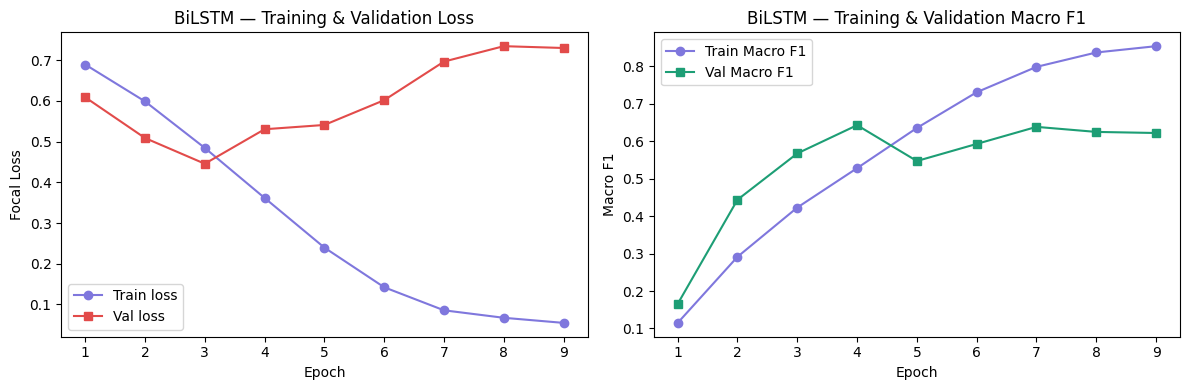

Saved: results/04_bilstm_training_curves.png


In [20]:
# ── 4.13  PLOT TRAINING CURVES ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ep = range(1, len(history['train_loss'])+1)

axes[0].plot(ep, history['train_loss'], 'o-', color='#7F77DD', label='Train loss')
axes[0].plot(ep, history['val_loss'],   's-', color='#E24B4A', label='Val loss')
axes[0].set_title('BiLSTM — Training & Validation Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Focal Loss')
axes[0].legend()

axes[1].plot(ep, history['train_f1'], 'o-', color='#7F77DD', label='Train Macro F1')
axes[1].plot(ep, history['val_f1'],   's-', color='#1D9E75', label='Val Macro F1')
axes[1].set_title('BiLSTM — Training & Validation Macro F1')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Macro F1')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/04_bilstm_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/04_bilstm_training_curves.png")


In [21]:
# ── 4.14  LOAD BEST MODEL & EVALUATE ON TEST ─────────────────
model.load_state_dict(torch.load('../models/bilstm_best.pt', map_location=DEVICE))
_, _, y_pred, y_test, y_proba = evaluate(model, test_loader)

test_macro_f1 = f1_score(y_test, y_pred, average='macro')
test_acc      = accuracy_score(y_test, y_pred)
test_auc      = roc_auc_score(
    label_binarize(y_test, classes=[0,1,2]),
    y_proba, multi_class='ovr', average='macro'
)

print("\n" + "=" * 60)
print("TEST SET EVALUATION — BiLSTM + Focal Loss")
print("=" * 60)
print(f"\n  Macro F1  : {test_macro_f1:.4f}  ← PRIMARY METRIC")
print(f"  Accuracy  : {test_acc:.4f}")
print(f"  ROC-AUC   : {test_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))


TEST SET EVALUATION — BiLSTM + Focal Loss

  Macro F1  : 0.6237  ← PRIMARY METRIC
  Accuracy  : 0.8170
  ROC-AUC   : 0.8376

Classification Report:
              precision    recall  f1-score   support

    Negative       0.67      0.73      0.70       131
     Neutral       0.20      0.37      0.26        70
    Positive       0.95      0.87      0.91       799

    accuracy                           0.82      1000
   macro avg       0.61      0.66      0.62      1000
weighted avg       0.86      0.82      0.84      1000



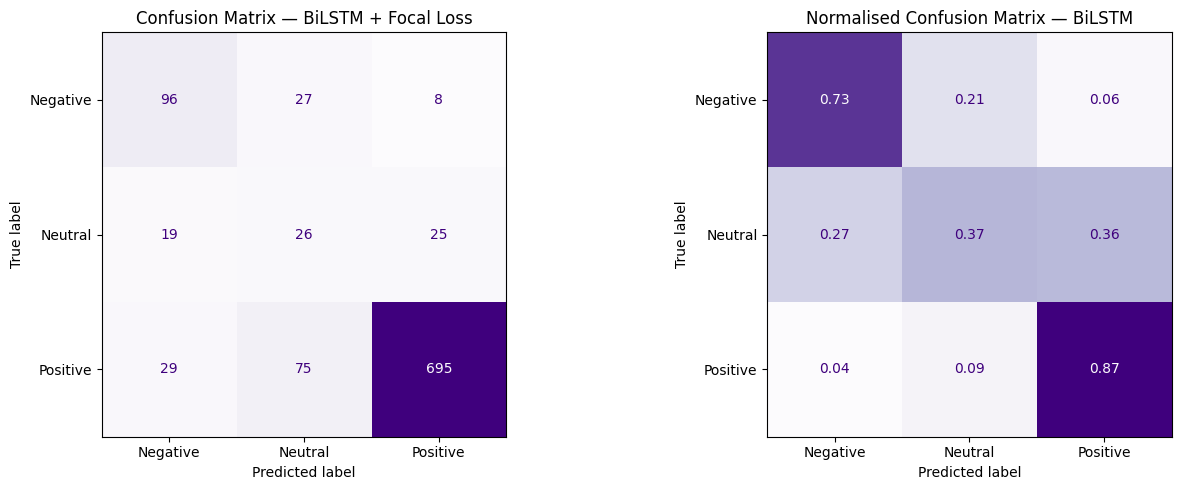


Dominant error: Positive → Neutral (75 cases)


In [22]:
# ── 4.15  CONFUSION MATRIX ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
    ax=axes[0], colorbar=False, cmap='Purples')
axes[0].set_title('Confusion Matrix — BiLSTM + Focal Loss')
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_norm, display_labels=CLASS_NAMES).plot(
    ax=axes[1], colorbar=False, cmap='Purples', values_format='.2f')
axes[1].set_title('Normalised Confusion Matrix — BiLSTM')
plt.tight_layout()
plt.savefig('../results/04_bilstm_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

# Dominant error mode
off_diag = [(cm[i,j], CLASS_NAMES[i], CLASS_NAMES[j])
            for i in range(3) for j in range(3) if i!=j]
worst = max(off_diag)
print(f"\nDominant error: {worst[1]} → {worst[2]} ({worst[0]} cases)")

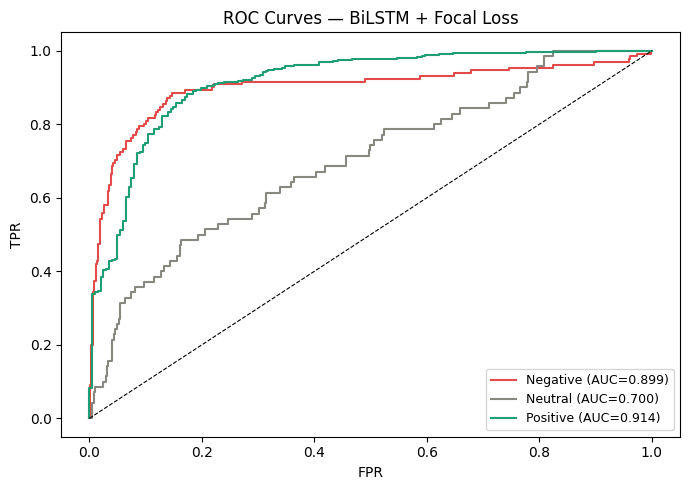

In [23]:
# ── 4.16  ROC CURVES ──────────────────────────────────────────
y_bin = label_binarize(y_test, classes=[0,1,2])
fig, ax = plt.subplots(figsize=(7,5))
for i, (name, col) in enumerate(zip(CLASS_NAMES, ['#E24B4A','#888780','#1D9E75'])):
    fpr, tpr, _ = roc_curve(y_bin[:,i], y_proba[:,i])
    ax.plot(fpr, tpr, color=col, lw=1.5, label=f'{name} (AUC={auc(fpr,tpr):.3f})')
ax.plot([0,1],[0,1],'k--',lw=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curves — BiLSTM + Focal Loss')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('../results/04_bilstm_roc.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
#4.17  SAVE RESULTS ────────────────────────────────────────
results = {
    'model': 'BiLSTM + Focal Loss',
    'macro_f1': round(test_macro_f1, 4),
    'accuracy': round(test_acc, 4),
    'roc_auc':  round(test_auc, 4),
    'best_val_f1': round(best_val_f1, 4),
    'hyperparams': {
        
        'embed_dim': EMBED_DIM, 'hidden_dim': HIDDEN_DIM,
        'focal_gamma': FOCAL_GAMMA, 'batch_size': BATCH_SIZE,
        'peak_lr': PEAK_LR, 'weight_decay': WEIGHT_DECAY
    }
}
with open('../results/04_results_bilstm.json', 'w') as f:
    json.dump(results, f, indent=2)

print("\n" + "=" * 60)
print("MODEL 2 RESULTS SUMMARY")
print("=" * 60)
print(f"  Macro F1  : {test_macro_f1:.4f}")
print(f"  Accuracy  : {test_acc:.4f}")
print(f"  ROC-AUC   : {test_auc:.4f}")



MODEL 2 RESULTS SUMMARY
  Macro F1  : 0.6237
  Accuracy  : 0.8170
  ROC-AUC   : 0.8376
